# Payment Methods Analysis

This notebook analyzes the cleaned payment methods dataset for the Italian Restaurant Analytics project.

The objective is to evaluate the distribution, usage, and monetary relevance of different payment methods, while identifying the most important payment channels and their behavior over time.

## Analysis Scope

- Payment method summary
- Top payment methods
- Payment method contribution
- Monthly payment trends
- Payment method concentration
- Key business insights

In [1]:
# Import the libraries required for data analysis and visualization

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
# Load the cleaned payment methods dataset and display the first five rows

df = pd.read_excel("../data/cleaned/payment_methods_cleaned.xlsx")
df.head()

,Date,Payment Method,Transactions,Sales
0,2025-03-01,TC. DINERS,616,34480.09
1,2025-03-01,MANUAL,40,0.00
2,2025-03-01,BENDO,2,0.00
3,2025-03-01,CANJE,1,39.00
4,2025-03-01,ORDEN DE CONSUMO,4,125.00


In [3]:
# Inspect the payment methods dataset structure, size, and data types

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset shape: (227, 4)

Column names:
['Date', 'Payment Method', 'Transactions', 'Sales']

Data types:
Date              datetime64[ns]
Payment Method            object
Transactions               int64
Sales                    float64
dtype: object


## Payment Method Summary

This section provides a general overview of payment activity, including total transactions, total sales, average sales per transaction, and the number of unique payment methods.

In [4]:
# Calculate key summary metrics for payment method activity

total_transactions = df["Transactions"].sum()
total_sales = df["Sales"].sum()
average_sales_per_transaction = total_sales / total_transactions
unique_payment_methods = df["Payment Method"].nunique()

print(f"Total transactions: {total_transactions:,}")
print(f"Total sales: ${total_sales:,.2f}")
print(f"Average sales per transaction: ${average_sales_per_transaction:,.2f}")
print(f"Unique payment methods: {unique_payment_methods}")

Total transactions: 28,552
Total sales: $1,552,185.55
Average sales per transaction: $54.36
Unique payment methods: 22


## Top Payment Methods by Sales

This section identifies the payment methods that generated the highest total sales during the analyzed period, helping determine which payment channels contributed the most revenue.

In [5]:
# Aggregate total sales by payment method and rank from highest to lowest

payment_sales = (
    df.groupby("Payment Method")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

payment_sales.head(10).style.format({
    "Sales": "${:,.2f}"
})

,Payment Method,Sales
0,TC. DINERS,"$395,902.18"
1,TC. VISA,"$353,691.02"
2,TD. VISA,"$274,220.15"
3,TC. MASTERCARD,"$257,354.16"
4,EFECTIVO,"$92,799.98"
5,TC.AMEX,"$44,562.36"
6,UBEREATS,"$39,221.83"
7,TC. DISCOVER,"$21,414.99"
8,RAPPI,"$19,264.04"
9,CUENTA X COBRAR,"$18,002.04"


### Top Payment Methods by Sales Visualization

The following horizontal bar chart shows the seven payment methods that generated the highest total sales during the analyzed period.

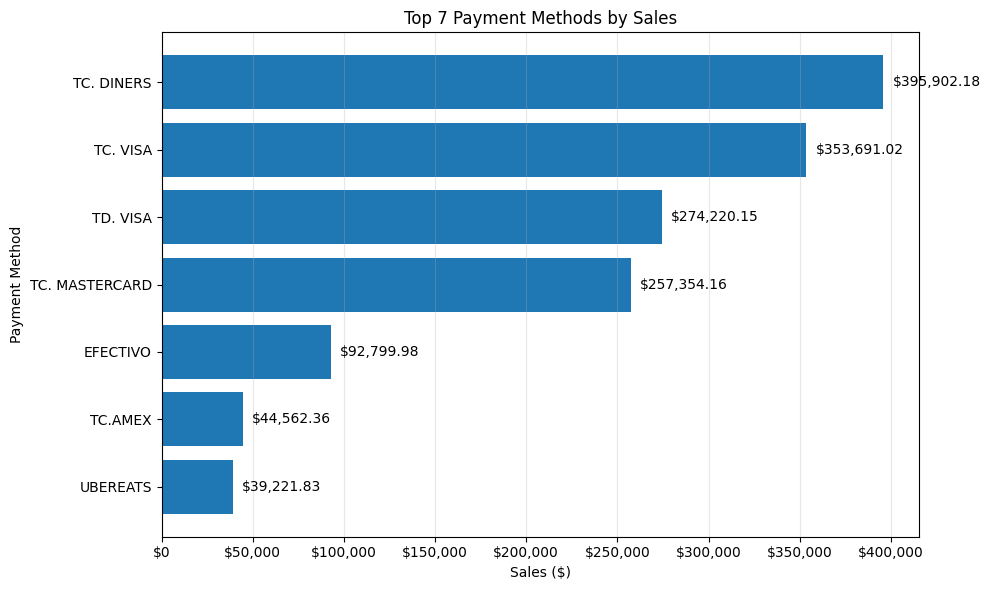

In [6]:
# Create a horizontal bar chart for the seven payment methods with the highest sales

top_payment_sales = payment_sales.head(7)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_payment_sales["Payment Method"],
    top_payment_sales["Sales"]
)

plt.title("Top 7 Payment Methods by Sales")
plt.xlabel("Sales ($)")
plt.ylabel("Payment Method")

# Display the highest-selling payment method at the top
plt.gca().invert_yaxis()

# Format the horizontal axis as currency
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

# Add sales labels at the end of each bar
for bar, value in zip(bars, top_payment_sales["Sales"]):
    plt.text(
        value + 5000,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.2f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

Card payments dominate the restaurant's sales structure. `TC. DINERS` generated the highest total sales at $395,902.18, followed by `TC. VISA` with $353,691.02, `TD. VISA` with $274,220.15, and `TC. MASTERCARD` with $257,354.16.

Cash represents a substantially smaller share of sales at $92,799.98, while alternative channels such as `TC.AMEX` and `UBEREATS` contribute at much lower levels.

Overall, the results indicate a strong customer preference for card-based payment methods, making electronic payment channels the primary source of processed sales.

## Top Payment Methods by Transactions

This section identifies the most frequently used payment methods during the analyzed period, helping compare transaction volume with the monetary contribution of each payment channel.

In [7]:
# Aggregate total transactions by payment method and rank from highest to lowest

payment_transactions = (
    df.groupby("Payment Method")["Transactions"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

payment_transactions.head(10)

,Payment Method,Transactions
0,TC. DINERS,6386
1,TC. VISA,5501
2,TD. VISA,4848
3,TC. MASTERCARD,4037
4,EFECTIVO,2565
5,UBEREATS,1315
6,RAPPI,784
7,TC.AMEX,638
8,MERMAS,617
9,MANUAL,595


### Top Payment Methods by Transactions Visualization

The following horizontal bar chart shows the seven most frequently used payment methods during the analyzed period.

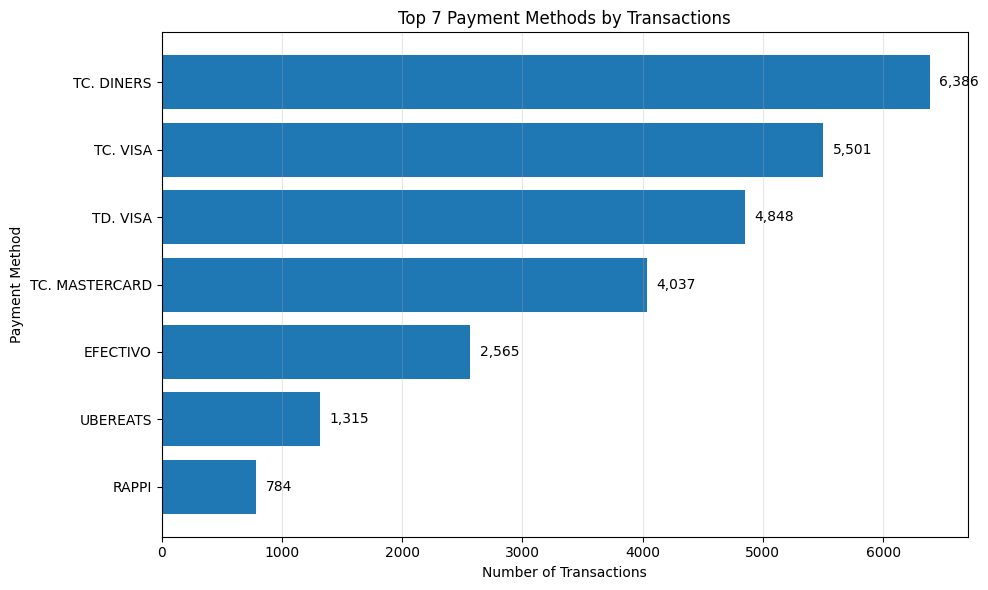

In [8]:
# Create a horizontal bar chart for the seven payment methods with the highest transaction volume

top_payment_transactions = payment_transactions.head(7)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_payment_transactions["Payment Method"],
    top_payment_transactions["Transactions"]
)

plt.title("Top 7 Payment Methods by Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("Payment Method")

# Display the most frequently used payment method at the top
plt.gca().invert_yaxis()

# Add transaction labels at the end of each bar
for bar, value in zip(
    bars,
    top_payment_transactions["Transactions"]
):
    plt.text(
        value + 80,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

`TC. DINERS` was the most frequently used payment method with 6,386 transactions, followed by `TC. VISA` with 5,501, `TD. VISA` with 4,848, and `TC. MASTERCARD` with 4,037.

Cash accounted for 2,565 transactions, while delivery platforms such as `UBEREATS` and `RAPPI` represented a smaller but still relevant share of payment activity.

The similarity between the transaction ranking and the sales ranking indicates that the restaurant's highest-revenue payment methods are also among the most frequently used, reinforcing the strong dominance of card-based payments.

## Average Sales per Transaction by Payment Method

This section analyzes the average monetary value generated per transaction for each payment method, helping identify channels associated with higher-value purchases.

In [9]:
# Calculate average sales per transaction for each payment method

payment_average = (
    df.groupby("Payment Method")
    .agg({
        "Transactions": "sum",
        "Sales": "sum"
    })
    .reset_index()
)

payment_average["Average Sales per Transaction"] = (
    payment_average["Sales"] / payment_average["Transactions"]
)

payment_average = payment_average.sort_values(
    "Average Sales per Transaction",
    ascending=False
)

payment_average.head(10).style.format({
    "Sales": "${:,.2f}",
    "Average Sales per Transaction": "${:,.2f}"
})

,Payment Method,Transactions,Sales,Average Sales per Transaction
2,CANJE SCALA,1,$941.62,$941.62
5,CUENTA X COBRAR,64,"$18,002.04",$281.28
1,CANJE,2,$240.39,$120.19
7,FACT REPROCESADA,13,"$1,439.50",$110.73
10,ORDEN DE CONSUMO,37,"$3,489.39",$94.31
3,CHEQUE,1,$92.64,$92.64
20,TRANSFERENCIA,113,"$8,378.23",$74.14
18,TC.AMEX,638,"$44,562.36",$69.85
17,TC. VISA,5501,"$353,691.02",$64.30
16,TC. MASTERCARD,4037,"$257,354.16",$63.75


### Representative Payment Methods

To avoid distorted results from payment methods with very few transactions, the following analysis focuses on methods with at least 100 recorded transactions.

This provides a more representative comparison of average transaction value across frequently used payment channels.

In [10]:
# Filter payment methods with at least 100 transactions and rank by average sales per transaction

payment_average_filtered = (
    payment_average[
        payment_average["Transactions"] >= 100
    ]
    .sort_values(
        "Average Sales per Transaction",
        ascending=False
    )
)

payment_average_filtered.style.format({
    "Sales": "${:,.2f}",
    "Average Sales per Transaction": "${:,.2f}"
})

,Payment Method,Transactions,Sales,Average Sales per Transaction
20,TRANSFERENCIA,113,"$8,378.23",$74.14
18,TC.AMEX,638,"$44,562.36",$69.85
17,TC. VISA,5501,"$353,691.02",$64.30
16,TC. MASTERCARD,4037,"$257,354.16",$63.75
14,TC. DINERS,6386,"$395,902.18",$62.00
15,TC. DISCOVER,347,"$21,414.99",$61.71
19,TD. VISA,4848,"$274,220.15",$56.56
6,EFECTIVO,2565,"$92,799.98",$36.18
21,UBEREATS,1315,"$39,221.83",$29.83
12,PEDIDOS YA,332,"$9,558.86",$28.79


### Average Sales per Transaction by Payment Method Visualization

The following horizontal bar chart compares the seven payment methods with the highest average sales per transaction among methods with at least 100 recorded transactions.

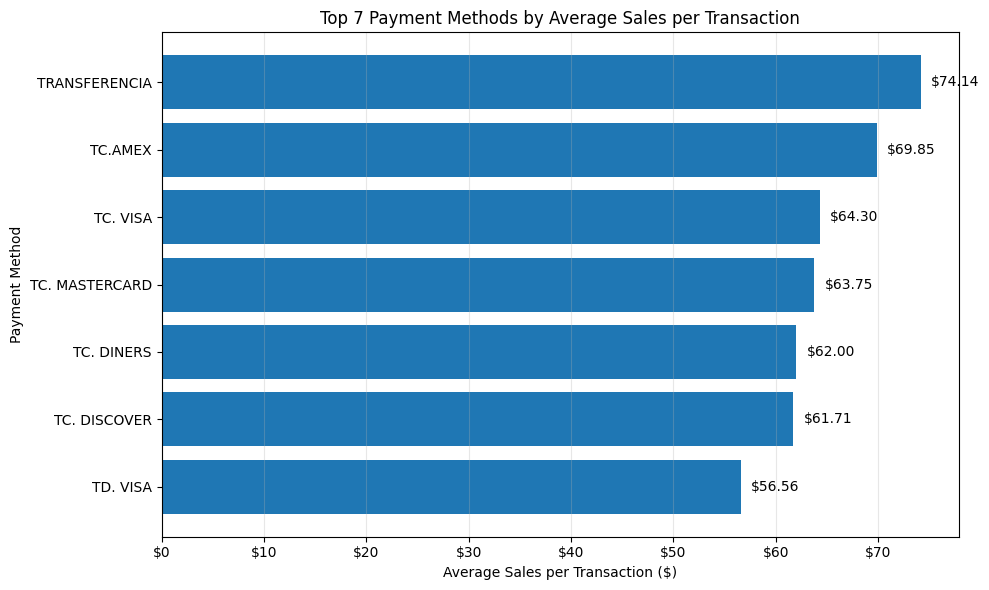

In [11]:
# Create a horizontal bar chart for the seven payment methods with the highest average sales per transaction

top_payment_average = payment_average_filtered.head(7)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_payment_average["Payment Method"],
    top_payment_average["Average Sales per Transaction"]
)

plt.title("Top 7 Payment Methods by Average Sales per Transaction")
plt.xlabel("Average Sales per Transaction ($)")
plt.ylabel("Payment Method")

# Display the highest average transaction value at the top
plt.gca().invert_yaxis()

# Format the horizontal axis as currency
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

# Add average transaction value labels at the end of each bar
for bar, value in zip(
    bars,
    top_payment_average["Average Sales per Transaction"]
):
    plt.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.2f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

Among payment methods with at least 100 recorded transactions, `TRANSFERENCIA` generated the highest average sales per transaction at $74.14, followed by `TC.AMEX` at $69.85.

Major card payment methods also showed relatively high average transaction values, including `TC. VISA` at $64.30, `TC. MASTERCARD` at $63.75, `TC. DINERS` at $62.00, and `TC. DISCOVER` at $61.71.

These results indicate that card-based payment methods combine both high transaction volume and relatively high transaction value, while the filtering approach prevents low-volume payment methods from disproportionately influencing the comparison.

## Payment Method Contribution

This section measures the percentage contribution of each payment method to total sales, helping identify which payment channels account for the largest share of revenue.

In [12]:
# Calculate the percentage contribution of each payment method to total sales

payment_contribution = payment_sales.copy()

payment_contribution["Contribution (%)"] = (
    payment_contribution["Sales"] / payment_contribution["Sales"].sum()
) * 100

payment_contribution.head(10).style.format({
    "Sales": "${:,.2f}",
    "Contribution (%)": "{:.2f}%"
})

,Payment Method,Sales,Contribution (%)
0,TC. DINERS,"$395,902.18",25.51%
1,TC. VISA,"$353,691.02",22.79%
2,TD. VISA,"$274,220.15",17.67%
3,TC. MASTERCARD,"$257,354.16",16.58%
4,EFECTIVO,"$92,799.98",5.98%
5,TC.AMEX,"$44,562.36",2.87%
6,UBEREATS,"$39,221.83",2.53%
7,TC. DISCOVER,"$21,414.99",1.38%
8,RAPPI,"$19,264.04",1.24%
9,CUENTA X COBRAR,"$18,002.04",1.16%


### Payment Method Contribution Visualization

The following horizontal bar chart shows the seven payment methods with the highest contribution to total sales during the analyzed period.

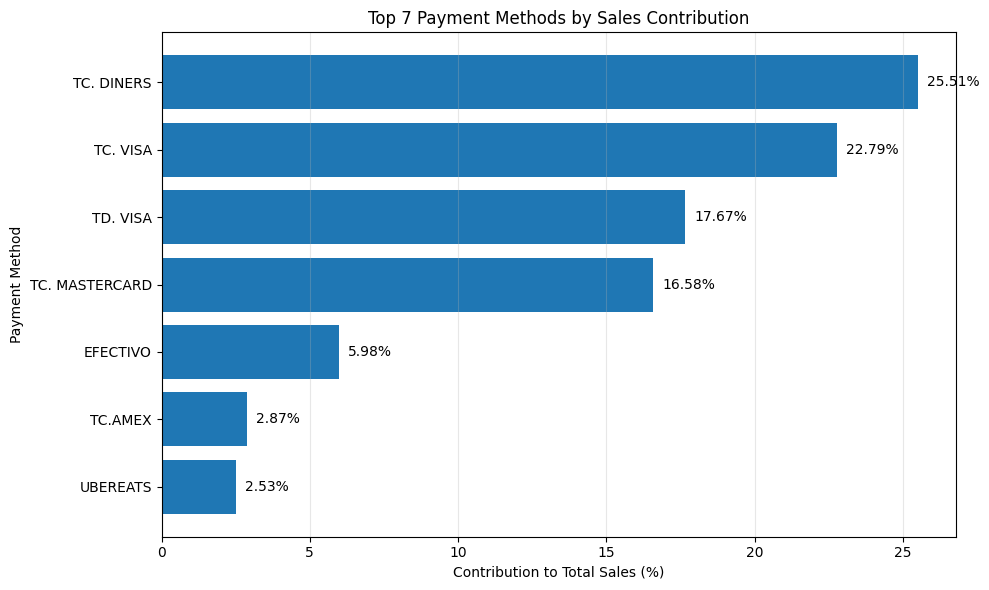

In [13]:
# Create a horizontal bar chart for the seven payment methods with the highest sales contribution

top_payment_contribution = payment_contribution.head(7)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_payment_contribution["Payment Method"],
    top_payment_contribution["Contribution (%)"]
)

plt.title("Top 7 Payment Methods by Sales Contribution")
plt.xlabel("Contribution to Total Sales (%)")
plt.ylabel("Payment Method")

# Display the largest contributor at the top
plt.gca().invert_yaxis()

# Add percentage labels at the end of each bar
for bar, value in zip(
    bars,
    top_payment_contribution["Contribution (%)"]
):
    plt.text(
        value + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The four leading card-based payment methods account for approximately 82.54% of total sales, demonstrating a very high concentration of revenue in electronic card payments.

`TC. DINERS` represents the largest individual share at 25.51%, followed by `TC. VISA` at 22.79%, `TD. VISA` at 17.67%, and `TC. MASTERCARD` at 16.58%.

Cash contributes only 5.98% of total sales, while alternative channels such as `TC.AMEX` and `UBEREATS` represent much smaller shares.

Overall, the payment structure is strongly concentrated in a small number of card-based channels, reinforcing their importance to the restaurant's revenue flow.

## Monthly Payment Trends

This section analyzes the monthly evolution of the leading payment methods, helping identify changes in customer payment preferences and variations in sales contribution over time.

In [14]:
# Select the four payment methods with the highest total sales

top_payment_methods = payment_sales.head(4)["Payment Method"].tolist()

top_payment_methods

['TC. DINERS', 'TC. VISA', 'TD. VISA', 'TC. MASTERCARD']

In [15]:
# Aggregate monthly sales for the leading payment methods

monthly_payment_sales = (
    df[df["Payment Method"].isin(top_payment_methods)]
    .groupby(["Date", "Payment Method"])["Sales"]
    .sum()
    .reset_index()
)

monthly_payment_sales.head(10).style.format({
    "Sales": "${:,.2f}"
})

,Date,Payment Method,Sales
0,2025-03-01 00:00:00,TC. DINERS,"$34,480.09"
1,2025-03-01 00:00:00,TC. MASTERCARD,"$19,137.92"
2,2025-03-01 00:00:00,TC. VISA,"$24,549.31"
3,2025-03-01 00:00:00,TD. VISA,"$20,143.59"
4,2025-04-01 00:00:00,TC. DINERS,"$25,381.69"
5,2025-04-01 00:00:00,TC. MASTERCARD,"$15,673.27"
6,2025-04-01 00:00:00,TC. VISA,"$20,630.88"
7,2025-04-01 00:00:00,TD. VISA,"$19,249.59"
8,2025-05-01 00:00:00,TC. DINERS,"$27,913.71"
9,2025-05-01 00:00:00,TC. MASTERCARD,"$21,709.13"


### Monthly Payment Trends Visualization

The following line chart compares the monthly sales evolution of the four leading payment methods, helping identify changes in payment behavior and relative performance over time.

In [16]:
# Reshape the monthly payment data for visualization

monthly_payment_pivot = monthly_payment_sales.pivot(
    index="Date",
    columns="Payment Method",
    values="Sales"
)

monthly_payment_pivot

Payment Method,TC. DINERS,TC. MASTERCARD,TC. VISA,TD. VISA
Date,,,,
2025-03-01,34480.09,19137.92,24549.31,20143.59
2025-04-01,25381.69,15673.27,20630.88,19249.59
2025-05-01,27913.71,21709.13,28972.87,22329.89
2025-06-01,32131.55,19315.35,25410.18,19454.65
2025-07-01,26782.09,20520.55,28881.24,20062.33
2025-08-01,27731.39,18119.94,27823.42,20415.95
2025-09-01,27550.61,19284.59,24189.94,18788.66
2025-10-01,29241.22,20105.60,26027.89,20587.69
2025-11-01,36793.14,21908.22,28597.53,24430.22


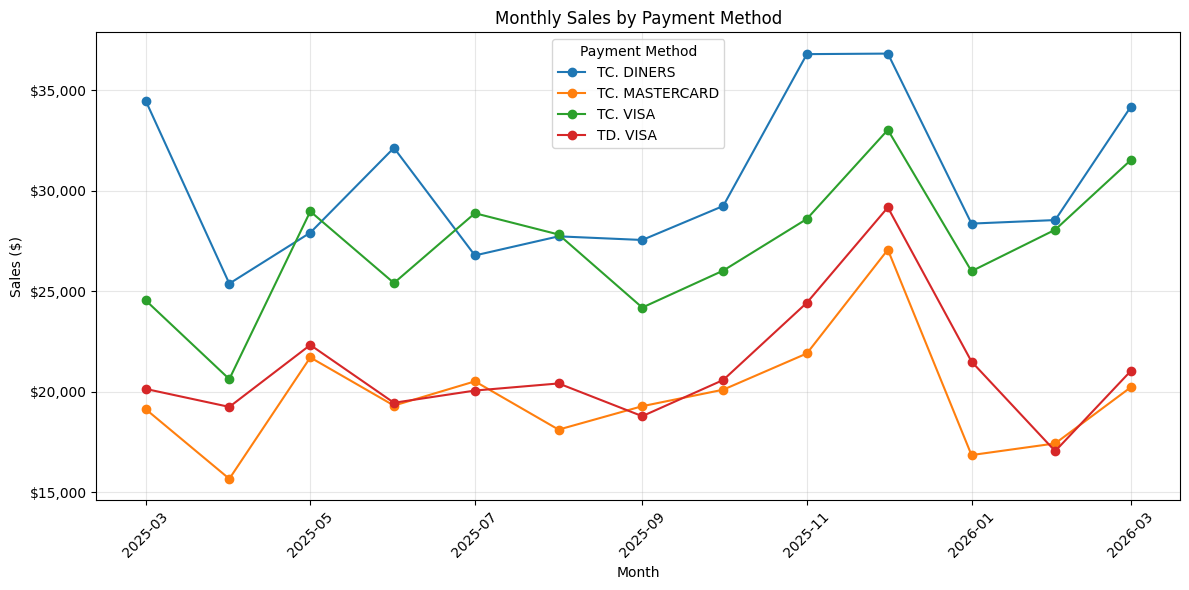

In [17]:
# Create a line chart to compare monthly sales across the leading payment methods

plt.figure(figsize=(12, 6))

for payment_method in monthly_payment_pivot.columns:
    plt.plot(
        monthly_payment_pivot.index,
        monthly_payment_pivot[payment_method],
        marker="o",
        label=payment_method
    )

plt.title("Monthly Sales by Payment Method")
plt.xlabel("Month")
plt.ylabel("Sales ($)")

# Format the vertical axis as currency
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.xticks(rotation=45)
plt.legend(title="Payment Method")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

`TC. DINERS` remained the leading payment method during most of the analyzed period, consistently generating the highest monthly sales among the four main payment channels.

The four leading card-based methods followed broadly similar monthly patterns, with stronger performance toward the end of 2025, particularly in November and December.

January 2026 shows a noticeable decline across the main payment methods, followed by a recovery in subsequent months. This suggests that changes in overall restaurant sales were reflected consistently across the dominant payment channels rather than being driven by a single payment method.

## Payment Method Concentration

This section measures how much of the restaurant's total sales are concentrated in the leading payment methods, helping evaluate the degree of dependency on a small number of payment channels.

In [18]:
# Calculate the share of total sales generated by the four leading payment methods

top_four_sales = payment_sales.head(4)["Sales"].sum()

top_four_concentration = (
    top_four_sales / total_sales
) * 100

print(f"Top 4 payment methods sales: ${top_four_sales:,.2f}")
print(f"Share of total sales: {top_four_concentration:.2f}%")

Top 4 payment methods sales: $1,281,167.51
Share of total sales: 82.54%


### Payment Method Concentration Visualization

The following chart compares the share of total sales generated by the four leading payment methods with the contribution of all remaining payment methods combined.

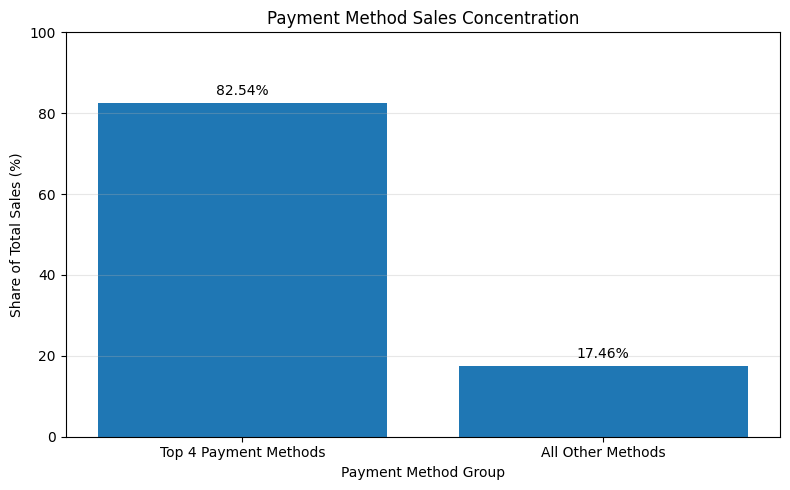

In [19]:
# Compare the sales concentration of the top four payment methods with all remaining methods

remaining_concentration = 100 - top_four_concentration

concentration_data = pd.DataFrame({
    "Group": [
        "Top 4 Payment Methods",
        "All Other Methods"
    ],
    "Share (%)": [
        top_four_concentration,
        remaining_concentration
    ]
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    concentration_data["Group"],
    concentration_data["Share (%)"]
)

plt.title("Payment Method Sales Concentration")
plt.xlabel("Payment Method Group")
plt.ylabel("Share of Total Sales (%)")

plt.ylim(0, 100)

for bar, value in zip(
    bars,
    concentration_data["Share (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The four leading payment methods account for 82.54% of total sales, while all remaining payment methods combined represent only 17.46%.

This indicates a high level of sales concentration in a small number of payment channels, particularly the major card-based methods.

The restaurant therefore relies heavily on its four dominant payment methods, making their availability and operational reliability especially important for maintaining normal sales activity.

## Payment Methods Analysis Summary

The payment methods analysis shows that the restaurant processed 28,552 transactions and generated $1,552,185.55 in total sales during the analyzed period, across 22 unique payment methods.

Card-based payments clearly dominate the restaurant's revenue structure. `TC. DINERS` generated the highest total sales at $395,902.18, followed by `TC. VISA` with $353,691.02, `TD. VISA` with $274,220.15, and `TC. MASTERCARD` with $257,354.16.

These four leading payment methods together accounted for approximately 82.54% of total sales, demonstrating a very high concentration of revenue in a small number of electronic payment channels.

Transaction volume followed a similar pattern, with the same major card methods also ranking among the most frequently used. This indicates that their high sales contribution is supported by both strong customer usage and relatively high transaction values.

Among payment methods with at least 100 recorded transactions, `TRANSFERENCIA` showed the highest average sales per transaction at $74.14, followed by `TC.AMEX` at $69.85. The major card methods also maintained comparatively high average transaction values, generally above $56 per transaction.

Monthly trends showed broadly similar movement across the leading payment methods, including stronger activity toward the end of 2025, a noticeable decline in January 2026, and subsequent recovery.

Overall, the restaurant's payment structure is strongly dependent on card-based channels, which represent the primary source of both transaction volume and sales revenue.

---

## Author

**Guido Acosta**

Data Analyst Portfolio Project

GitHub Portfolio – 2026